In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [21]:
def plot_x_vs_y(df, x_column, y_column, x_label, y_label, country, init=None):
    # Group by 'd' and iterate over each group

    method_dic = {"optimized": "Opt Poverty Rate Policy",
                  "conditional_optimized": "Opt Poverty Gap Policy"}
    
    df = df[df.numfeatures.isin([1, 2, 3, 4])]
    df = df.sort_values(by=x_column).reset_index()
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)  # 2x2 grid for subplots
    for i, (d, group) in enumerate(df.groupby('d')):
        # Determine subplot index
        row = i // 2
        col = i % 2
        ax = axs[row, col]

        # Iterate over each method
        for method, method_group in group.groupby('policy'):
            # Plot y_column against x_column
            x_col = method_group[x_column].copy()
            y_col = method_group[y_column].copy()
            if init:
                init_x, init_y = init
                if init_x is None:
                    x_col.loc[-1] = 0.
                else:
                    x_col.loc[-1] = method_group[init_x].iloc[0]
                x_col.index = x_col.index + 1
                x_col = x_col.sort_index()
                if init_y is None:
                    y_col.loc[-1] = 0.
                else:
                    y_col.loc[-1] = method_group[init_y].iloc[0]
                y_col.index = y_col.index + 1
                y_col = y_col.sort_index()
            ax.plot(list(x_col), list(y_col), label=method_dic[method], marker="o")

        # if x_column == "unconditional_tolerance" and y_column == "post_transfer_poverty_rate":
        #     ax.plot(method_group[x_column], method_group[x_column], label="y=x", linestyle="dashed", color="black")

        # Add labels and title to each subplot
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f'd={d}')
        ax.legend()

        # Add grid
        ax.grid(True)

    # Adjust layout and display plot
    plt.suptitle("{}: {} vs. {}".format(country, y_label, x_label))
    plt.tight_layout()
    plt.savefig("figs/{}_{}_{}.pdf".format(country.lower(), x_column, y_column))
    plt.show()



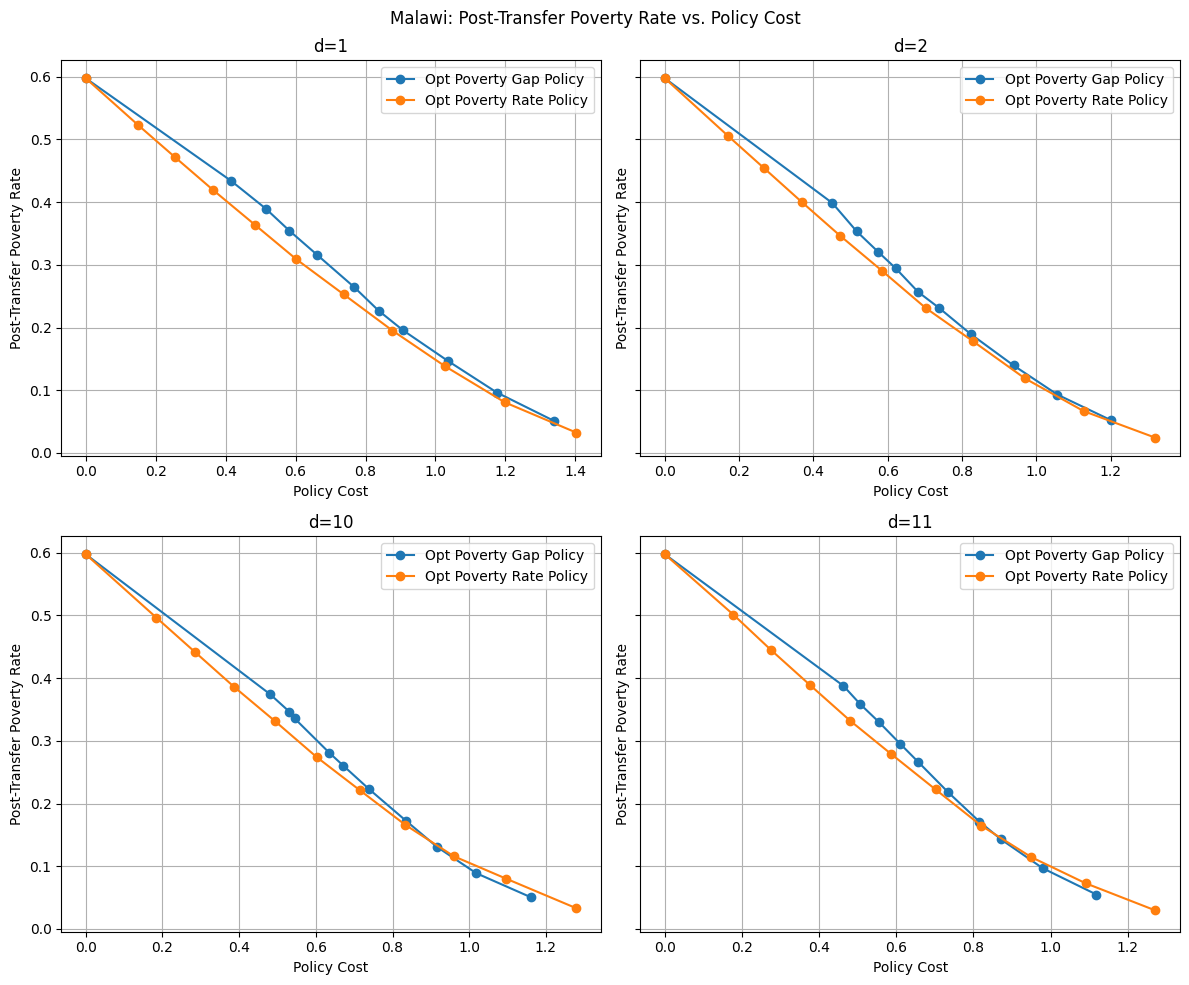

In [22]:
df = pd.read_csv("results/all_pool=central.csv")
plot_x_vs_y(df, 'policy_cost', 'post_transfer_poverty_rate', 'Policy Cost', 'Post-Transfer Poverty Rate',  'Malawi', init= (None,"initial_poverty_rate"))